# 双向循环神经网络

## 基础知识

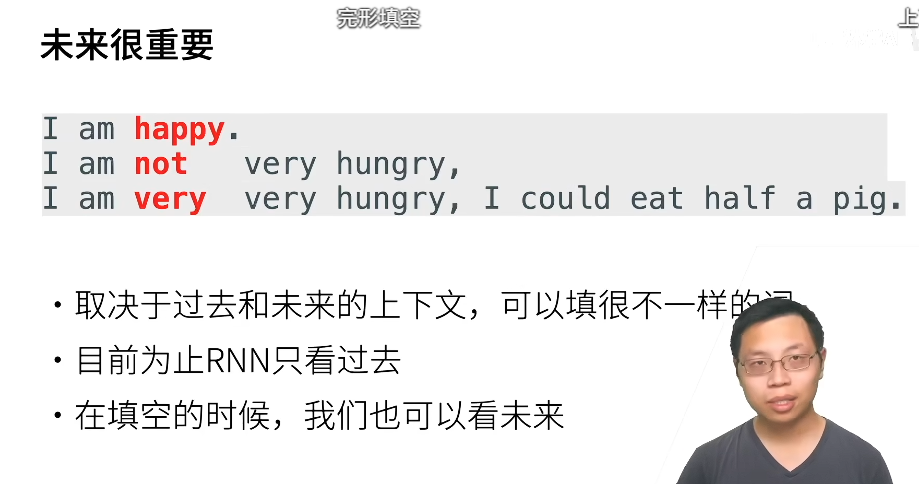

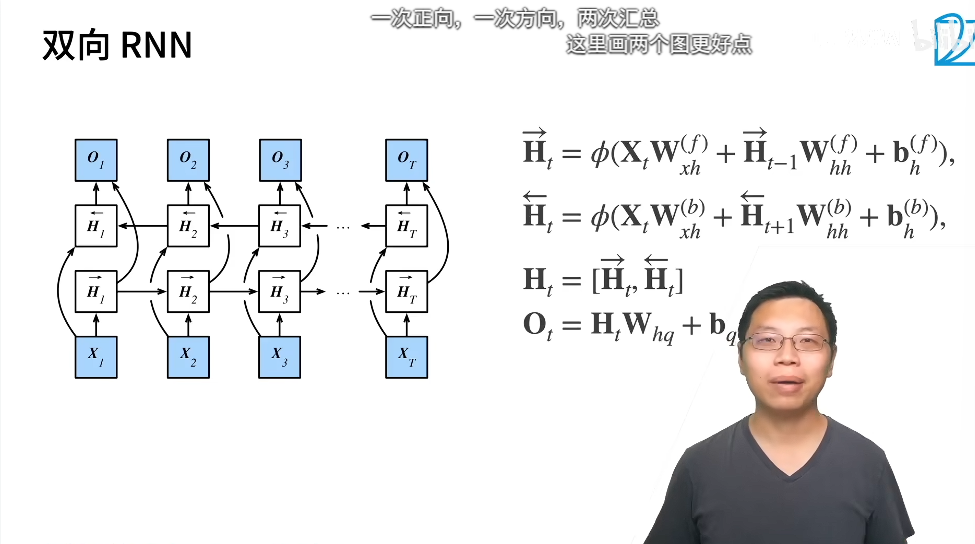

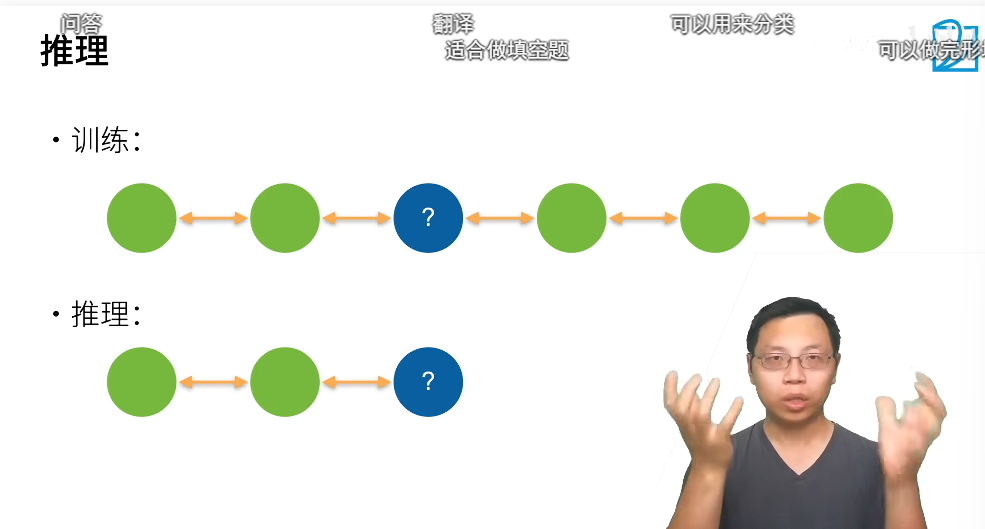

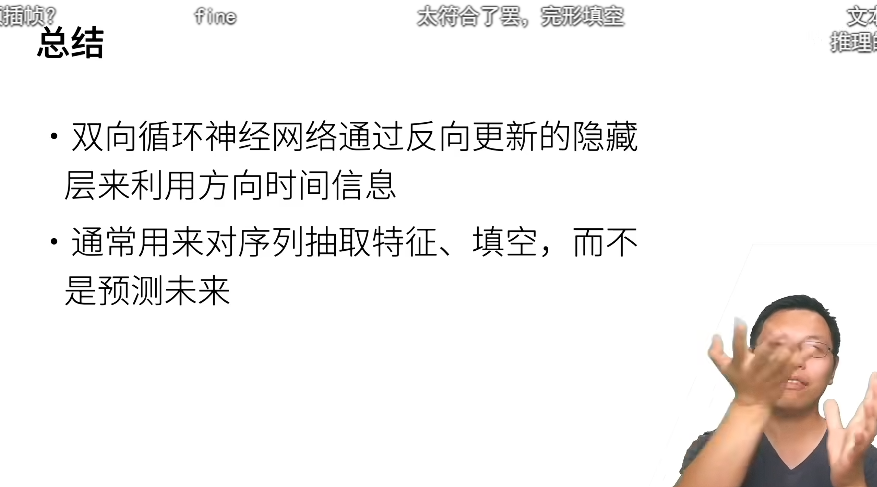

双向循环神经网络（Bi-RNN，包括 Bi-GRU、Bi-LSTM）的核心特点是：能同时“看到”过去和未来的上下文信息。

基于这个特性，它最适合解决那些“当前时刻的判断严重依赖完整语境”的问题。但它有一个致命的限制：必须拿到完整的输入序列后才能工作（不能用于实时流式预测）。

## 代码

调用lstm模型结构时写一个bidirectional=True即可

perplexity 1.1, 4492.7 tokens/sec on cpu
time travellerererererererererererererererererererererererererer
travellerererererererererererererererererererererererererer


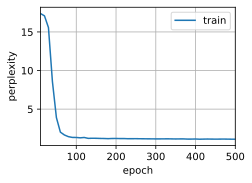

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

# 加载数据
batch_size, num_steps, device = 32, 35, d2l.try_gpu()
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)
# 通过设置“bidirective=True”来定义双向LSTM模型
vocab_size, num_hiddens, num_layers = len(vocab), 256, 2
num_inputs = vocab_size
lstm_layer = nn.LSTM(num_inputs, num_hiddens, num_layers, bidirectional=True)
model = d2l.RNNModel(lstm_layer, len(vocab))
model = model.to(device)
# 训练模型
num_epochs, lr = 500, 1
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)